<a href="https://colab.research.google.com/github/Keerthi291890/Prediction-of-Photovoltaic-Properties-ofDyes-usingDeeplearning/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
data = pd.read_csv('/content/finaldataset.csv')
print(data.columns)
print("Missing values before cleaning:")
print(data.isnull().sum())
data = data.dropna()
print("Missing values after cleaning:")
print(data.isnull().sum())
print("Infinite values before cleaning:")
print(np.isinf(data.select_dtypes(include=np.number)).sum())
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()
for col in data.columns:
    if data[col].dtype == 'object':
        try:
            data[col] = pd.to_numeric(data[col])
        except ValueError:
            print(f"Could not convert column '{col}' to numeric. Check its contents.")
descriptor_columns = [col for col in data.columns if col not in ['SMILES', 'Solvent', 'Absorption_Maxima', 'LUMO', 'Bandgap', 'Lambda max (nm)', 'lumo', 'Bandgap']]
X_dye = data[descriptor_columns]
solvent_names = data['Solvent']
y = data[['Lambda max (nm)', 'lumo', 'Bandgap']]
for col in X_dye.columns:
    if X_dye[col].nunique() == 1:
        print(f"Column '{col}' has zero variance and will be dropped.")
        X_dye = X_dye.drop(col, axis=1)
scaler = StandardScaler()
X_dye = scaler.fit_transform(X_dye)
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_solvent = enc.fit_transform(np.array(solvent_names).reshape(-1, 1))
X_full = np.concatenate([X_dye, X_solvent], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)
input_layer = Input(shape=(X_train.shape[1],))
x = Dense(512, activation='relu', kernel_initializer='he_normal')(input_layer)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu', kernel_initializer='he_normal')(x)
x = Dropout(0.2)(x)
x = Dense(128, activation='relu', kernel_initializer='he_normal')(x)
output = Dense(3)(x)
model = Model(inputs=input_layer, outputs=output)
optimizer = Adam(learning_rate=0.0005, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping])
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MSE (Loss): {loss:.4f}")
print(f"Test MAE (Mean Absolute Error): {mae:.4f}")
model.save('fnn_dye_model.keras')
import joblib
joblib.dump(scaler, 'fnn_scaler.pkl')
joblib.dump(enc, 'fnn_solvent_encoder.pkl')
joblib.dump(descriptor_columns, 'fnn_descriptor_columns.pkl')




Index(['TSRW10', 'MATS5se', 'nN', 'AXp-7d', 'NaasC', 'Xc-5dv', 'Xch-5dv',
       'GATS4dv', 'AXp-4d', 'AATSC5are', 'nHBAcc', 'ATSC5are', 'ATSC5se',
       'piPC10', 'AXp-3d', 'PEOE_VSA5', 'SlogP_VSA10', 'GGI4', 'SlogP_VSA1',
       'SMILES', 'Lambda max (nm)', 'Solvent', 'lumo', 'Bandgap'],
      dtype='object')
Missing values before cleaning:
TSRW10             4256
MATS5se            4256
nN                 4256
AXp-7d             4256
NaasC              4256
Xc-5dv             4256
Xch-5dv            4256
GATS4dv            4256
AXp-4d             4256
AATSC5are          4256
nHBAcc             4256
ATSC5are           4256
ATSC5se            4256
piPC10             4256
AXp-3d             4256
PEOE_VSA5          4256
SlogP_VSA10        4256
GGI4               4256
SlogP_VSA1         4256
SMILES             4253
Lambda max (nm)    4253
Solvent            4253
lumo               4253
Bandgap            4253
dtype: int64
Missing values after cleaning:
TSRW10             0
MATS5se      

['fnn_descriptor_columns.pkl']

In [ ]:
from google.colab import files

files.download('fnn_dye_model.keras')  # or 'dye_model.h5'
files.download('fnn_scaler.pkl')
files.download('fnn_solvent_encoder.pkl')
files.download('fnn_descriptor_columns.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 32/275 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(


275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


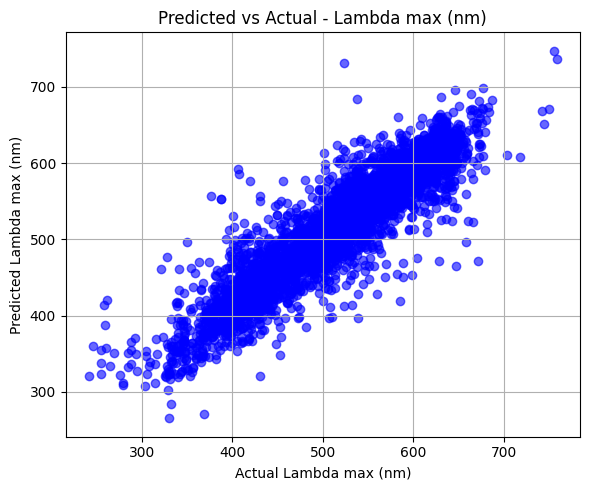

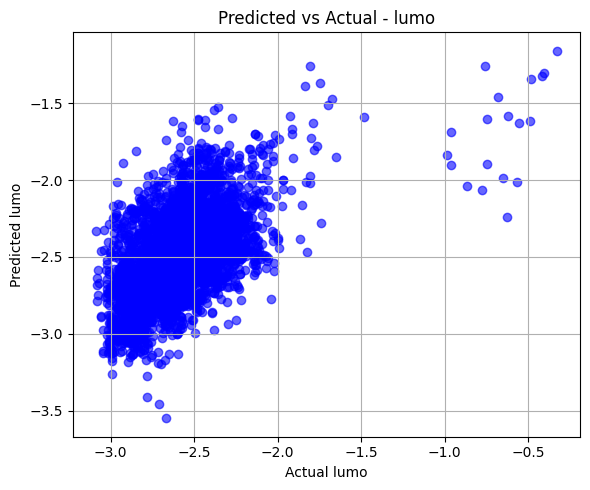

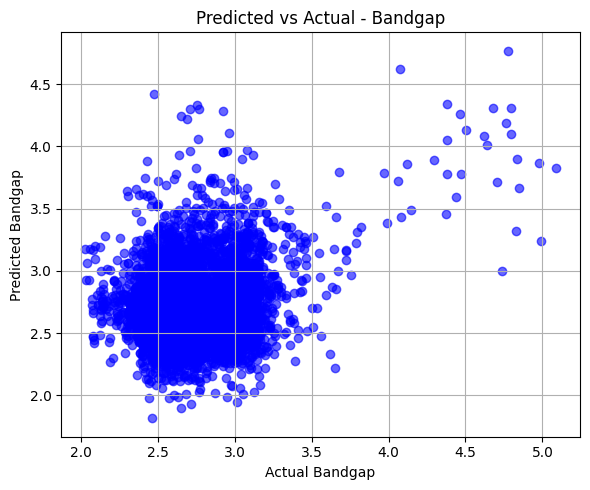

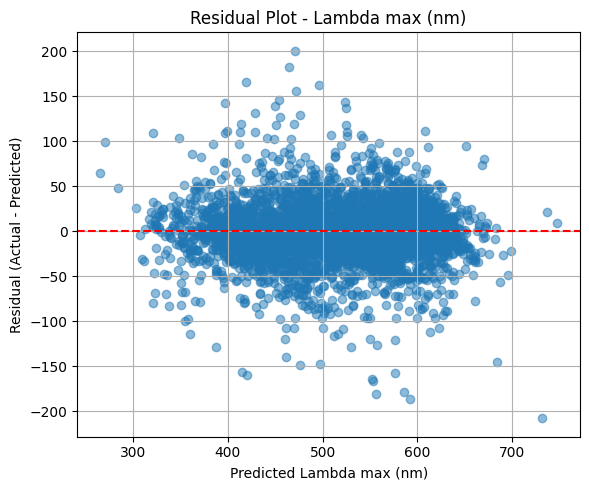

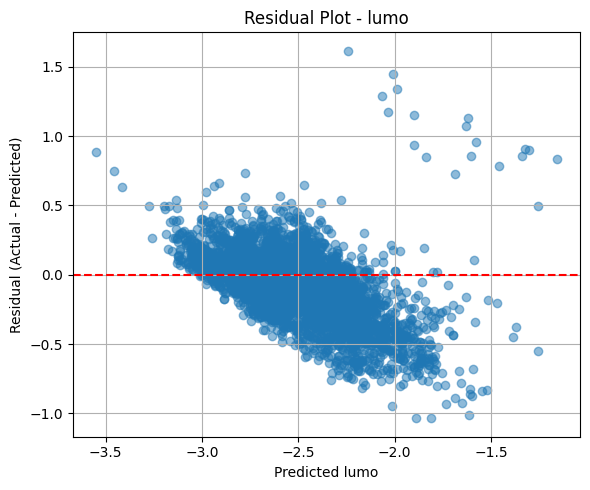

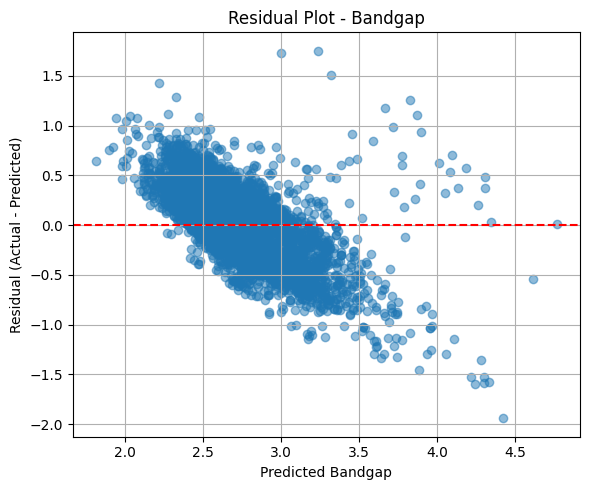

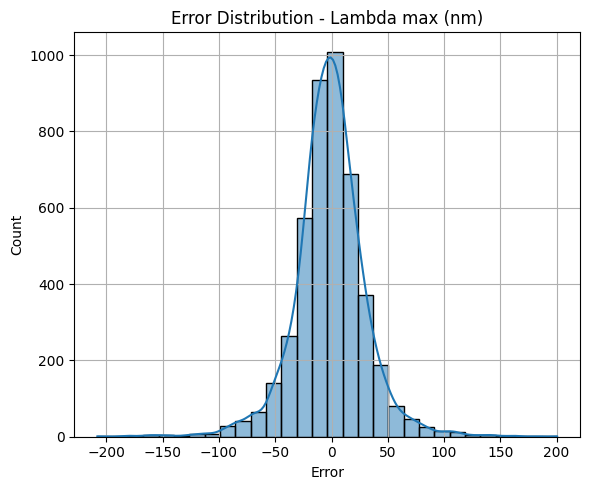

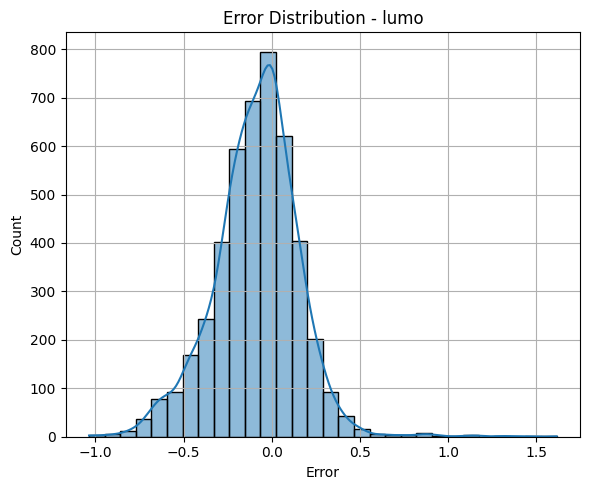

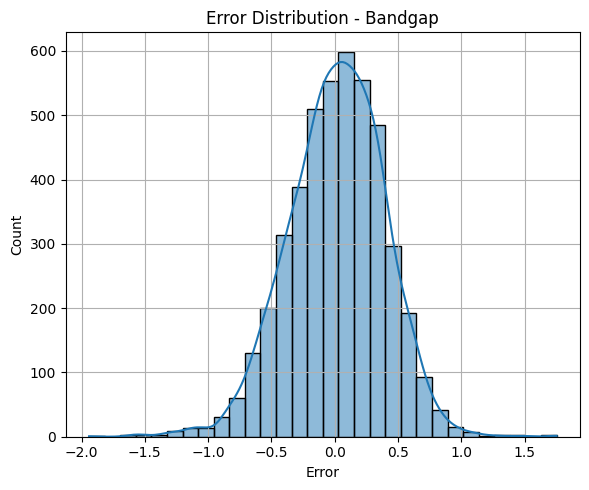

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
import joblib

# Load model and preprocessing
model = load_model('fnn_dye_model.keras')
scaler = joblib.load('fnn_scaler.pkl')
encoder = joblib.load('fnn_solvent_encoder.pkl')
descriptor_columns = joblib.load('fnn_descriptor_columns.pkl')

# Load test dataset
data = pd.read_csv('/content/finaldataset.csv')
X_dye = data[descriptor_columns]
X_solvent = encoder.transform(data[['Solvent']])
X_scaled = scaler.transform(X_dye)
X_input = np.concatenate([X_scaled, X_solvent], axis=1)

# True and predicted values
y_true = data[['Lambda max (nm)', 'lumo', 'Bandgap']].values
y_pred = model.predict(X_input)

# Names of the output properties
targets = ['Lambda max (nm)', 'lumo', 'Bandgap']

# 1. Predicted vs Actual
for i, name in enumerate(targets):
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.6, color='blue')
    plt.plot([y_true[:, i].min(), y_true[:, i].max()],
             [y_true[:, i].min(), y_true[:, i].max()], 'r--')
    plt.xlabel(f'Actual {name}')
    plt.ylabel(f'Predicted {name}')
    plt.title(f'Predicted vs Actual - {name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 2. Residual Plot
for i, name in enumerate(targets):
    residuals = y_true[:, i] - y_pred[:, i]
    plt.figure(figsize=(6, 5))
    plt.scatter(y_pred[:, i], residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(f'Predicted {name}')
    plt.ylabel('Residual (Actual - Predicted)')
    plt.title(f'Residual Plot - {name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 3. Error Distribution (Histogram)
for i, name in enumerate(targets):
    errors = y_true[:, i] - y_pred[:, i]
    plt.figure(figsize=(6, 5))
    sns.histplot(errors, kde=True, bins=30)
    plt.xlabel('Error')
    plt.title(f'Error Distribution - {name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Concatenate, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
df = pd.read_csv("/content/finaldataset.csv")
print("Missing values before cleaning:")
print(df.isnull().sum())
df = df.dropna()
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nInfinite values before cleaning:")
print(np.isinf(df.select_dtypes(include=np.number)).sum())
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

print("\nInfinite values after cleaning:")
print(np.isinf(df.select_dtypes(include=np.number)).sum())
print("\nEnsuring correct data types...")
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = pd.to_numeric(df[col])
        except ValueError:
            print(f"Could not convert column '{col}' to numeric. Check its contents.")
smiles_list = df['SMILES'].astype(str).tolist()
solvent_list = df['Solvent'].astype(str).tolist()
y = df[['Lambda max (nm)', 'lumo', 'Bandgap']].values
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(smiles_list)
smiles_seq = tokenizer.texts_to_sequences(smiles_list)
maxlen = max(len(seq) for seq in smiles_seq)
X_smiles = pad_sequences(smiles_seq, maxlen=maxlen, padding='post')

solvent_vocab = sorted(set(solvent_list))
solvent_to_index = {s: i for i, s in enumerate(solvent_vocab)}
X_solvent = np.array([solvent_to_index[s] for s in solvent_list])
X_smiles_train, X_smiles_test, X_solvent_train, X_solvent_test, y_train, y_test = train_test_split(
    X_smiles, X_solvent, y, test_size=0.2, random_state=42
)
smiles_input = Input(shape=(maxlen,), name='smiles_input')
#CNN MODEL
x1 = Embedding(input_dim=len(tokenizer.word_index)+1, output_dim=64)(smiles_input)
x1 = Conv1D(filters=64, kernel_size=3, activation='relu')(x1)
x1 = GlobalMaxPooling1D()(x1)
x1 = Dense(64, activation='relu')(x1)
solvent_input = Input(shape=(1,), name='solvent_input')
x2 = Embedding(input_dim=len(solvent_vocab), output_dim=16)(solvent_input)
x2 = Flatten()(x2)
x2 = Dense(16, activation='relu')(x2)
combined = Concatenate()([x1, x2])
x = Dense(64, activation='relu')(combined)
x = Dense(32, activation='relu')(x)
output = Dense(3, activation='linear', name='output')(x)

model = Model(inputs=[smiles_input, solvent_input], outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(
    [X_smiles_train, X_solvent_train],
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32
)

loss, mae = model.evaluate([X_smiles_test, X_solvent_test], y_test)
print(f"Loss: {loss}, MAE: {mae}")
model.save('Cnn_dye_model.keras')
import joblib
joblib.dump(tokenizer, 'Cnn_tokenizer.pkl')
joblib.dump(solvent_to_index, 'Cnn_solvent_encoder.pkl')
joblib.dump(maxlen, 'Cnn_maxlen.pkl')
joblib.dump(solvent_vocab, 'Cnn_solvent_vocab.pkl')
tokenizer = joblib.load('Cnn_tokenizer.pkl')
solvent_to_index = joblib.load('Cnn_solvent_encoder.pkl')
maxlen = joblib.load('Cnn_maxlen.pkl')


Missing values before cleaning:
TSRW10             4256
MATS5se            4256
nN                 4256
AXp-7d             4256
NaasC              4256
Xc-5dv             4256
Xch-5dv            4256
GATS4dv            4256
AXp-4d             4256
AATSC5are          4256
nHBAcc             4256
ATSC5are           4256
ATSC5se            4256
piPC10             4256
AXp-3d             4256
PEOE_VSA5          4256
SlogP_VSA10        4256
GGI4               4256
SlogP_VSA1         4256
SMILES             4253
Lambda max (nm)    4253
Solvent            4253
lumo               4253
Bandgap            4253
dtype: int64
Missing values after cleaning:
TSRW10             0
MATS5se            0
nN                 0
AXp-7d             0
NaasC              0
Xc-5dv             0
Xch-5dv            0
GATS4dv            0
AXp-4d             0
AATSC5are          0
nHBAcc             0
ATSC5are           0
ATSC5se            0
piPC10             0
AXp-3d             0
PEOE_VSA5          0
SlogP_VSA10 

275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


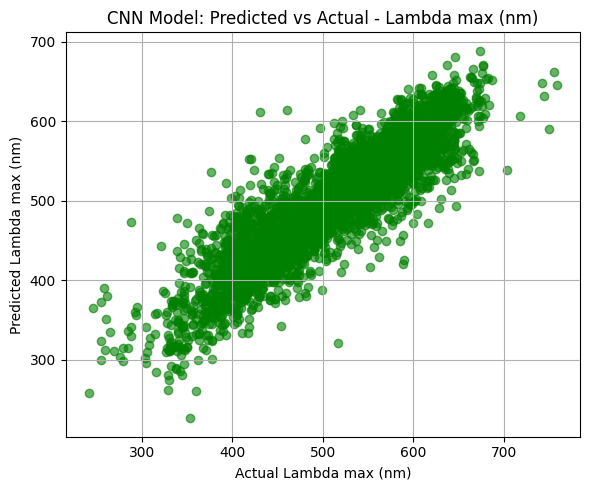

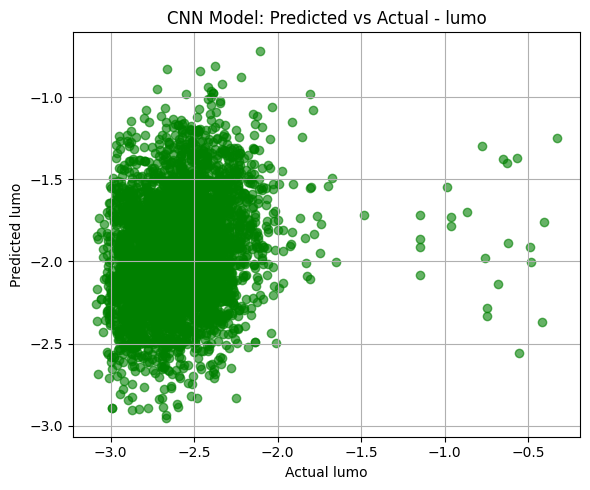

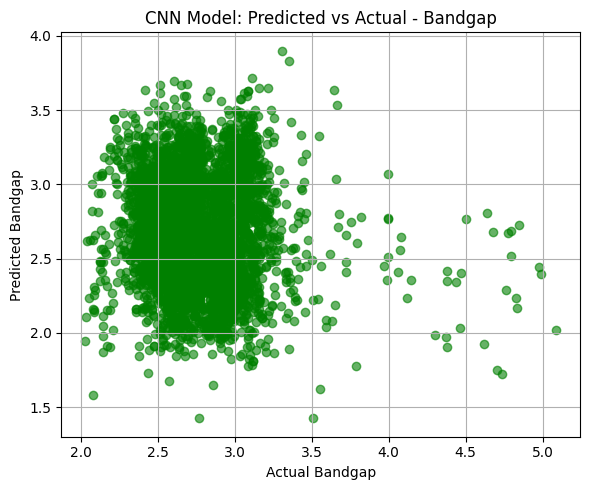

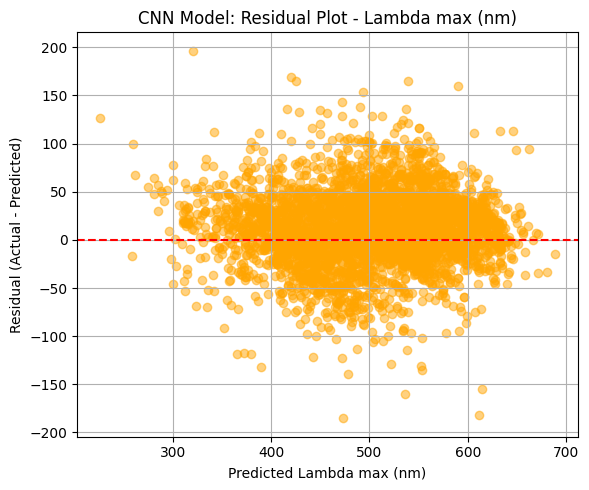

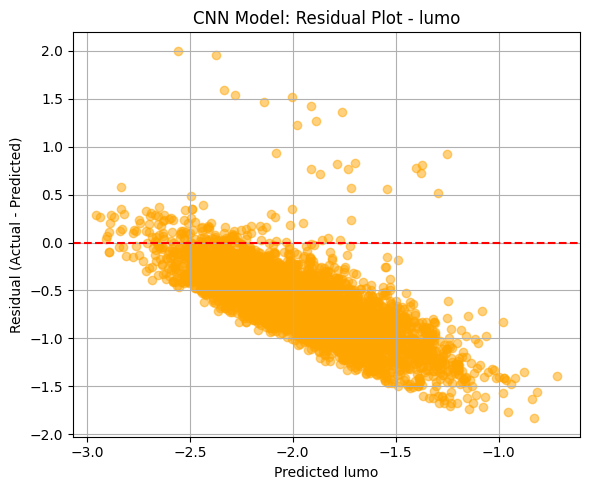

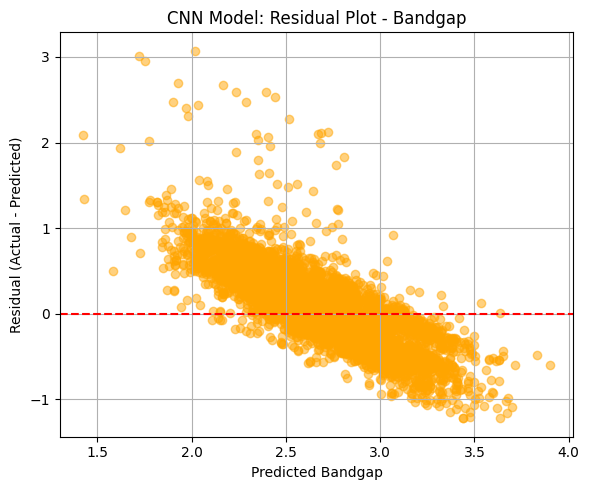

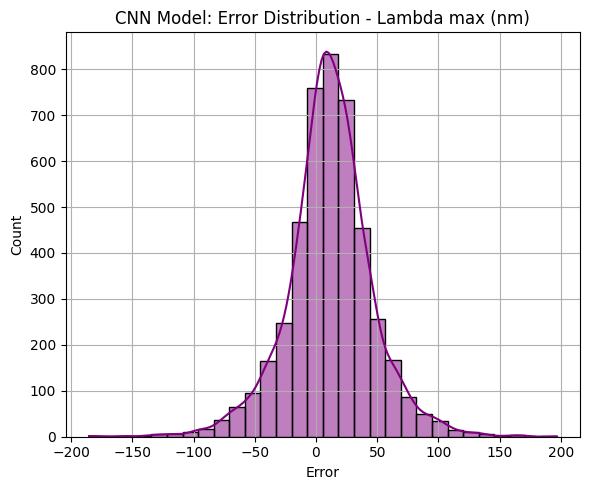

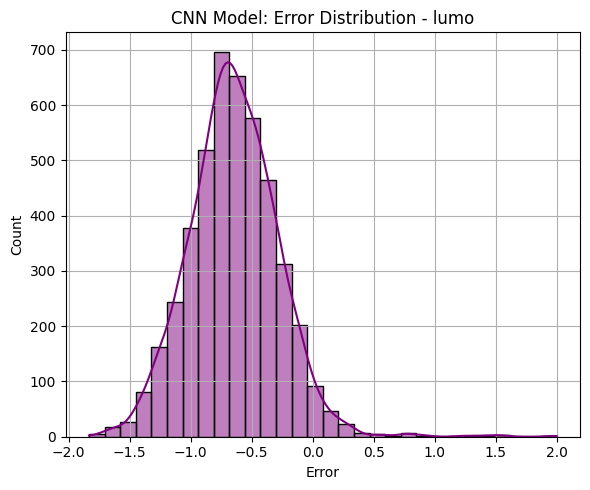

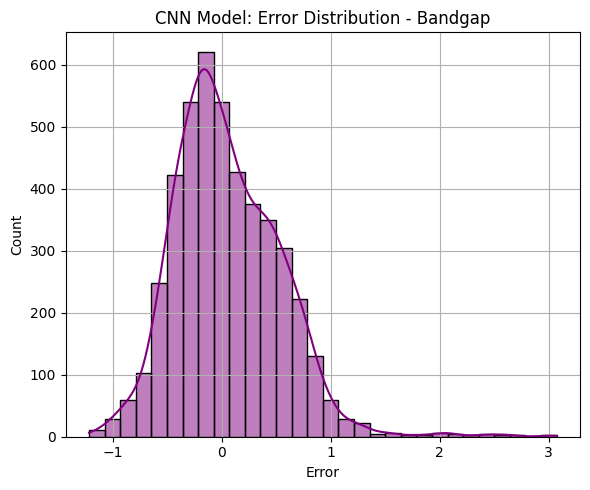

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
import joblib
from tensorflow.keras.preprocessing.sequence import pad_sequences
cnn_model = load_model('Cnn_dye_model.keras')
cnn_tokenizer = joblib.load('Cnn_tokenizer.pkl')
cnn_encoder = joblib.load('Cnn_solvent_encoder.pkl')
cnn_maxlen = joblib.load('Cnn_maxlen.pkl')
data = pd.read_csv('/content/finaldataset.csv')
smiles = data['SMILES'].astype(str).tolist()
X_smiles_seq = cnn_tokenizer.texts_to_sequences(smiles)
X_smiles_pad = pad_sequences(X_smiles_seq, maxlen=cnn_maxlen, padding='post')
solvent_test = data['Solvent'].astype(str).tolist()
X_solvent = np.array([cnn_encoder.get(s, -1) for s in solvent_test])
X_solvent = X_solvent.reshape(-1, 1)
X_input = [X_smiles_pad, X_solvent]
y_true = data[['Lambda max (nm)', 'lumo', 'Bandgap']].values
y_pred = cnn_model.predict(X_input)
targets = ['Lambda max (nm)', 'lumo', 'Bandgap']
for i, name in enumerate(targets):
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.6, color='green')
    plt.plot([y_true[:, i].min(), y_true[:, i].max()],
             [y_true[:, i].min(), y_true[:, i].max()], 'r--')
    plt.xlabel(f'Actual {name}')
    plt.ylabel(f'Predicted {name}')
    plt.title(f'CNN Model: Predicted vs Actual - {name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
for i, name in enumerate(targets):
    residuals = y_true[:, i] - y_pred[:, i]
    plt.figure(figsize=(6, 5))
    plt.scatter(y_pred[:, i], residuals, alpha=0.5, color='orange')
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(f'Predicted {name}')
    plt.ylabel('Residual (Actual - Predicted)')
    plt.title(f'CNN Model: Residual Plot - {name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
for i, name in enumerate(targets):
    errors = y_true[:, i] - y_pred[:, i]
    plt.figure(figsize=(6, 5))
    sns.histplot(errors, kde=True, bins=30, color='purple')
    plt.xlabel('Error')
    plt.title(f'CNN Model: Error Distribution - {name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import joblib
import itertools
data = pd.read_csv('/content/finaldataset.csv')
print("Missing values before cleaning:")
print(data.isnull().sum())
data = data.dropna()
print("\nMissing values after cleaning:")
print(data.isnull().sum())
print("\nInfinite values before cleaning:")
print(np.isinf(data.select_dtypes(include=np.number)).sum())
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

print("\nInfinite values after cleaning:")
print(np.isinf(data.select_dtypes(include=np.number)).sum())
print("\nEnsuring correct data types...")
for col in data.columns:
    if data[col].dtype == 'object':
        try:
            data[col] = pd.to_numeric(data[col])
        except ValueError:
            print(f"Could not convert column '{col}' to numeric. It might contain non-numeric strings.")

exclude_cols = ['SMILES', 'Solvent', 'Absorption_Maxima', 'LUMO', 'Bandgap', 'Lambda max (nm)', 'lumo', 'Bandgap']
descriptor_columns = [col for col in data.columns if col not in exclude_cols and data[col].dtype in [np.number]]
print(f"\nUsing {len(descriptor_columns)} descriptor columns.")
X_dye_df = data[descriptor_columns].copy()
solvent_names = data['Solvent']
target_cols = ['Lambda max (nm)', 'lumo', 'Bandgap']
available_target_cols = [col for col in target_cols if col in data.columns]
if not available_target_cols:
    raise ValueError("None of the target columns ('Lambda max (nm)', 'lumo', 'Bandgap') found in the data!")
print(f"Using target columns: {available_target_cols}")
y = data[available_target_cols].copy()
print("\nChecking for zero variance columns...")

cols_to_drop = []
for col in X_dye_df.columns:
    if X_dye_df[col].nunique() == 1:
        print(f"Column '{col}' has zero variance and will be dropped.")
        cols_to_drop.append(col)
X_dye_df = X_dye_df.drop(columns=cols_to_drop)

descriptor_columns = [col for col in descriptor_columns if col not in cols_to_drop]
print(f"Dropped {len(cols_to_drop)} zero-variance columns. {len(descriptor_columns)} remaining.")
print("\nHandling remaining NaN/inf in features and targets...")
X_dye_df.replace([np.inf, -np.inf], np.nan, inplace=True)
y.replace([np.inf, -np.inf], np.nan, inplace=True)
print("NaNs in features before imputation:", X_dye_df.isnull().sum().sum())
print("NaNs in targets before imputation:", y.isnull().sum().sum())

X_dye_df.fillna(X_dye_df.mean(), inplace=True)
y.fillna(y.mean(), inplace=True)
print("NaNs in features after imputation:", X_dye_df.isnull().sum().sum())
print("NaNs in targets after imputation:", y.isnull().sum().sum())
print("\nScaling features...")

scaler = StandardScaler()
X_dye_scaled = scaler.fit_transform(X_dye_df)
print("Encoding solvent names...")
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_solvent = enc.fit_transform(np.array(solvent_names).reshape(-1, 1))
print("Merging features...")
X_full = np.concatenate([X_dye_scaled, X_solvent], axis=1)
print(f"Full feature matrix shape: {X_full.shape}")
print("Splitting data...")

y_np = y.values
X_train, X_test, y_train, y_test = train_test_split(X_full, y_np, test_size=0.2, random_state=42)
print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

def create_mlp_model(input_shape, num_outputs, num_layers=3, units=256, dropout_rate=0.2, learning_rate=0.001):
    input_layer = Input(shape=input_shape)
    x = input_layer
    for i in range(num_layers):
        x = Dense(units, activation='relu', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout_rate)(x)
    output = Dense(num_outputs)(x)
    model = Model(inputs=input_layer, outputs=output)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

param_grid = {
   'num_layers': [2, 3, 4],
    'units': [128, 256, 512],
    'dropout_rate': [0.1, 0.2, 0.3],
    'learning_rate': [0.0001, 0.0005, 0.001]
}
def train_and_evaluate(params):
    print(f"Training with parameters: {params}")
    model = create_mlp_model(
        input_shape=(X_train.shape[1],),
        num_outputs=y_train.shape[1],
        num_layers=params['num_layers'],
        units=params['units'],
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate']
    )

    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=0)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    print(f"  -> Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")
    return mae, model

print("\nStarting hyperparameter search...")
best_params = None
best_mae = float('inf')
best_model = None
keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
print(f"Total parameter combinations to test: {len(param_combinations)}")
for i, params in enumerate(param_combinations):
    print(f"\n--- Combination {i+1}/{len(param_combinations)} ---")
    mae, current_model = train_and_evaluate(params)
    if mae < best_mae:
        print(f"  *** New best MAE found: {mae:.4f} (Previous best: {best_mae:.4f}) ***")
        best_mae = mae
        best_params = params
        best_model = current_model
print(f"\n--- Hyperparameter Search Complete ---")
print(f"Best Parameters Found: {best_params}")
print(f"Best Test MAE Achieved: {best_mae:.4f}")

if best_model is not None:
    print("\nSaving the best model...")
    best_model.save('dye_model.keras')
    print("Best model saved to dye_model.keras")
    print("Saving preprocessing objects...")
    joblib.dump(scaler, 'scaler.pkl')
    joblib.dump(enc, 'solvent_encoder.pkl')
    joblib.dump(descriptor_columns, 'descriptor_columns.pkl')
    print("Scaler, encoder, and column list saved.")
else:
    print("Error: No best model was found or trained successfully. Nothing saved.")

Missing values before cleaning:
TSRW10             4256
MATS5se            4256
nN                 4256
AXp-7d             4256
NaasC              4256
Xc-5dv             4256
Xch-5dv            4256
GATS4dv            4256
AXp-4d             4256
AATSC5are          4256
nHBAcc             4256
ATSC5are           4256
ATSC5se            4256
piPC10             4256
AXp-3d             4256
PEOE_VSA5          4256
SlogP_VSA10        4256
GGI4               4256
SlogP_VSA1         4256
SMILES             4253
Lambda max (nm)    4253
Solvent            4253
lumo               4253
Bandgap            4253
dtype: int64

Missing values after cleaning:
TSRW10             0
MATS5se            0
nN                 0
AXp-7d             0
NaasC              0
Xc-5dv             0
Xch-5dv            0
GATS4dv            0
AXp-4d             0
AATSC5are          0
nHBAcc             0
ATSC5are           0
ATSC5se            0
piPC10             0
AXp-3d             0
PEOE_VSA5          0
SlogP_VSA10

<ipython-input-1-d3f66aeb011a>:41: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  descriptor_columns = [col for col in data.columns if col not in exclude_cols and data[col].dtype in [np.number]] # Only include numeric cols


  -> Test Loss: 73814.2656, Test MAE: 157.2416
  *** New best MAE found: 157.2416 (Previous best: inf) ***

--- Combination 2/81 ---
Training with parameters: {'num_layers': 2, 'units': 128, 'dropout_rate': 0.1, 'learning_rate': 0.0005}
  -> Test Loss: 434.9691, Test MAE: 8.8257
  *** New best MAE found: 8.8257 (Previous best: 157.2416) ***

--- Combination 3/81 ---
Training with parameters: {'num_layers': 2, 'units': 128, 'dropout_rate': 0.1, 'learning_rate': 0.001}
  -> Test Loss: 397.2975, Test MAE: 8.2156
  *** New best MAE found: 8.2156 (Previous best: 8.8257) ***

--- Combination 4/81 ---
Training with parameters: {'num_layers': 2, 'units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.0001}
  -> Test Loss: 74264.0234, Test MAE: 157.7274

--- Combination 5/81 ---
Training with parameters: {'num_layers': 2, 'units': 128, 'dropout_rate': 0.2, 'learning_rate': 0.0005}
  -> Test Loss: 432.4741, Test MAE: 8.8528

--- Combination 6/81 ---
Training with parameters: {'num_layers': 2, 'uni

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(


275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


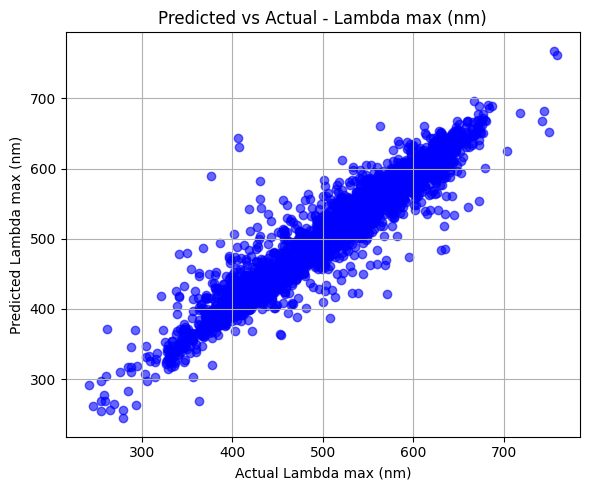

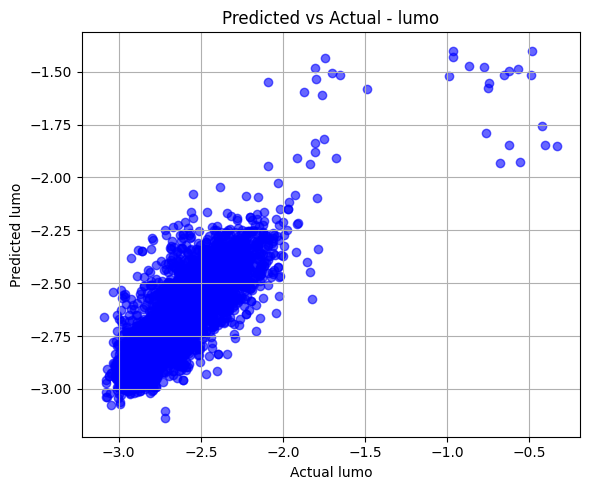

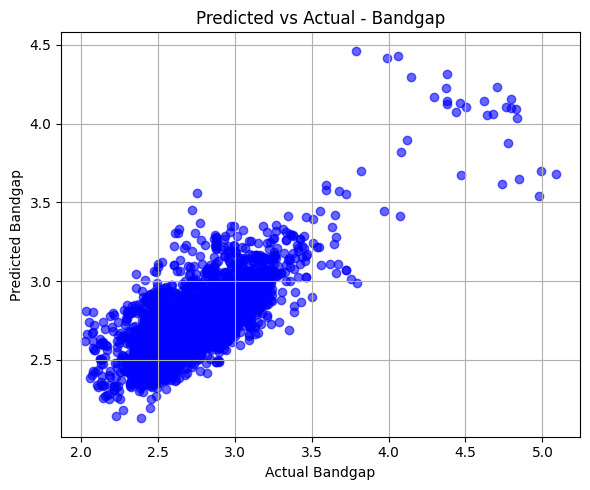

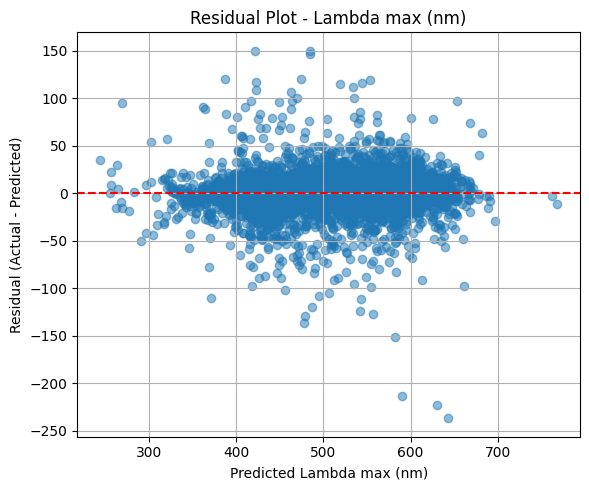

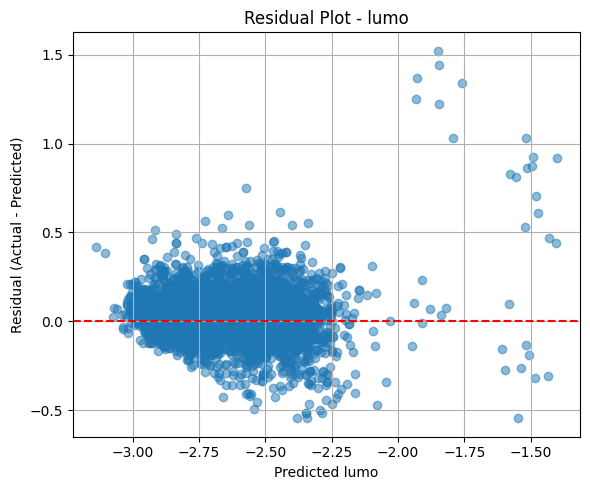

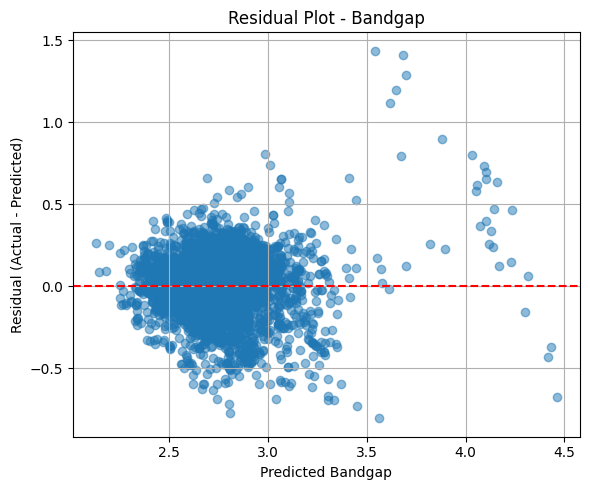

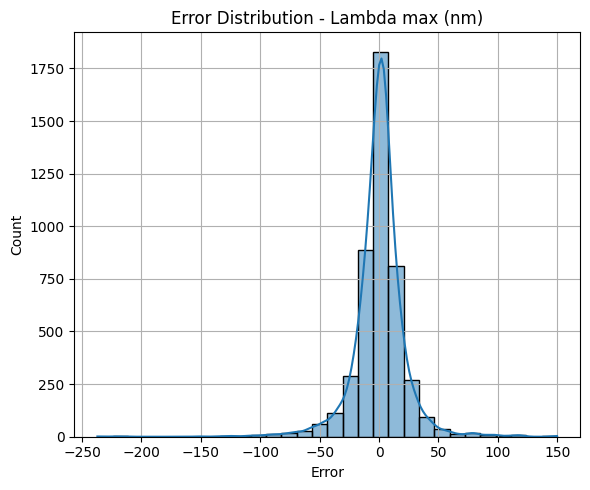

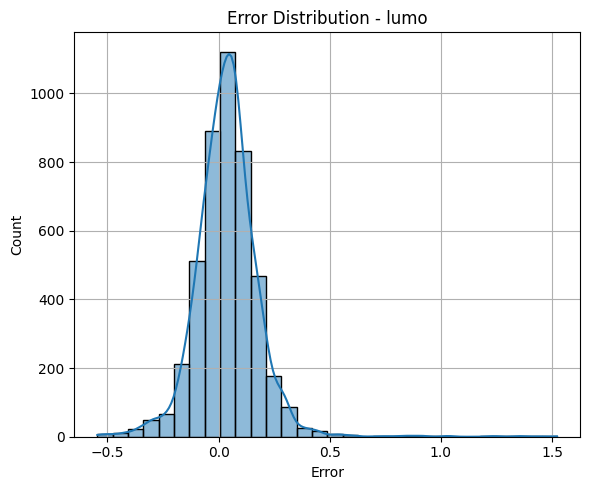

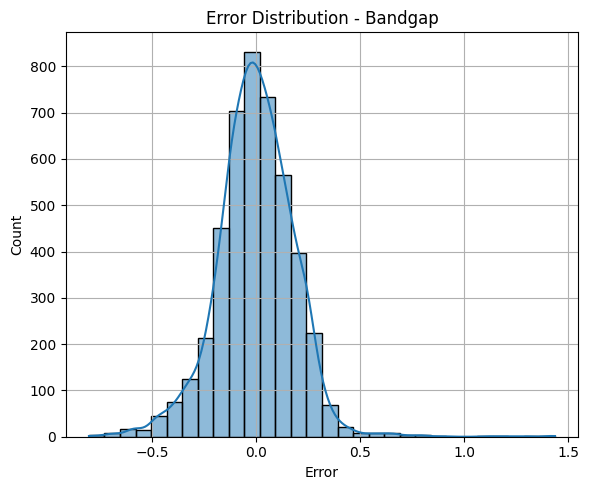

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
import joblib
model = load_model('dye_model.keras')
scaler = joblib.load('scaler.pkl')
encoder = joblib.load('solvent_encoder.pkl')
descriptor_columns = joblib.load('descriptor_columns.pkl')
data = pd.read_csv('/content/finaldataset.csv')
X_dye = data[descriptor_columns]
X_solvent = encoder.transform(data[['Solvent']])
X_scaled = scaler.transform(X_dye)
X_input = np.concatenate([X_scaled, X_solvent], axis=1)
y_true = data[['Lambda max (nm)', 'lumo', 'Bandgap']].values
y_pred = model.predict(X_input)
targets = ['Lambda max (nm)', 'lumo', 'Bandgap']
for i, name in enumerate(targets):
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.6, color='blue')
    plt.plot([y_true[:, i].min(), y_true[:, i].max()],
             [y_true[:, i].min(), y_true[:, i].max()], 'r--')
    plt.xlabel(f'Actual {name}')
    plt.ylabel(f'Predicted {name}')
    plt.title(f'Predicted vs Actual - {name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
for i, name in enumerate(targets):
    residuals = y_true[:, i] - y_pred[:, i]
    plt.figure(figsize=(6, 5))
    plt.scatter(y_pred[:, i], residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(f'Predicted {name}')
    plt.ylabel('Residual (Actual - Predicted)')
    plt.title(f'Residual Plot - {name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 3. Error Distribution (Histogram)
for i, name in enumerate(targets):
    errors = y_true[:, i] - y_pred[:, i]
    plt.figure(figsize=(6, 5))
    sns.histplot(errors, kde=True, bins=30)
    plt.xlabel('Error')
    plt.title(f'Error Distribution - {name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
import joblib
from tensorflow.keras.models import load_model

fnn_model = load_model('fnn_dye_model.keras')

fnn_scaler = joblib.load('fnn_scaler.pkl')
fnn_encoder = joblib.load('fnn_solvent_encoder.pkl')
fnn_descriptor_cols = joblib.load('fnn_descriptor_columns.pkl')
cnn_model = load_model('Cnn_dye_model.keras')

cnn_tokenizer = joblib.load('Cnn_tokenizer.pkl')
cnn_encoder = joblib.load('Cnn_solvent_encoder.pkl')
cnn_maxlen = joblib.load('Cnn_maxlen.pkl')

mlp_model = load_model('dye_model.keras')

mlp_scaler = joblib.load('scaler.pkl')
mlp_encoder = joblib.load('solvent_encoder.pkl')
mlp_descriptor_cols = joblib.load('descriptor_columns.pkl')

import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences

df = pd.read_csv("/content/finaldataset.csv").dropna()

target_cols = ['Lambda max (nm)', 'lumo', 'Bandgap']
y = df[target_cols].values
solvent_list = df['Solvent'].astype(str).tolist()
smiles_list = df['SMILES'].astype(str).tolist()

_, X_test_df, _, y_test = train_test_split(df, y, test_size=0.2, random_state=42)
solvent_test = X_test_df['Solvent'].astype(str).tolist()
smiles_test = X_test_df['SMILES'].astype(str).tolist()



fnn_model = load_model('fnn_dye_model.keras')
fnn_scaler = joblib.load('fnn_scaler.pkl')
fnn_enc = joblib.load('fnn_solvent_encoder.pkl')
fnn_desc = joblib.load('fnn_descriptor_columns.pkl')
X_dye = fnn_scaler.transform(X_test_df[fnn_desc])
X_solvent = fnn_enc.transform(np.array(solvent_test).reshape(-1, 1))
X_fnn = np.concatenate([X_dye, X_solvent], axis=1)
y_pred_fnn = fnn_model.predict(X_fnn)
mse_fnn = mean_squared_error(y_test, y_pred_fnn)
mae_fnn = mean_absolute_error(y_test, y_pred_fnn)
r2_fnn = r2_score(y_test, y_pred_fnn)

cnn_model = load_model('Cnn_dye_model.keras')
cnn_tokenizer = joblib.load('Cnn_tokenizer.pkl')
cnn_encoder = joblib.load('Cnn_solvent_encoder.pkl')
cnn_maxlen = joblib.load('Cnn_maxlen.pkl')

smiles_seq = cnn_tokenizer.texts_to_sequences(smiles_test)
X_smiles_test = pad_sequences(smiles_seq, maxlen=cnn_maxlen, padding='post')
X_solvent_test = np.array([cnn_encoder.get(s, -1) for s in solvent_test])
X_solvent_test = X_solvent_test.reshape(-1, 1)
y_pred_cnn = cnn_model.predict([X_smiles_test, X_solvent_test])

mse_cnn = mean_squared_error(y_test, y_pred_cnn)
mae_cnn = mean_absolute_error(y_test, y_pred_cnn)
r2_cnn = r2_score(y_test, y_pred_cnn)

mlp_model = load_model('dye_model.keras')
mlp_scaler = joblib.load('scaler.pkl')
mlp_enc = joblib.load('solvent_encoder.pkl')
mlp_desc = joblib.load('descriptor_columns.pkl')
X_dye = mlp_scaler.transform(X_test_df[mlp_desc])
X_solvent = mlp_enc.transform(np.array(solvent_test).reshape(-1, 1))
X_mlp = np.concatenate([X_dye, X_solvent], axis=1)
y_pred_mlp = mlp_model.predict(X_mlp)

mse_mlp = mean_squared_error(y_test, y_pred_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)
print("Model Comparison:")
print(f"FNN  - MSE: {mse_fnn:.4f}, MAE: {mae_fnn:.4f}, R2: {r2_fnn:.4f}")
print(f"CNN  - MSE: {mse_cnn:.4f}, MAE: {mae_cnn:.4f}, R2: {r2_cnn:.4f}")
print(f"MLP  - MSE: {mse_mlp:.4f}, MAE: {mae_mlp:.4f}, R2: {r2_mlp:.4f}")


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Model Comparison:
FNN  - MSE: 486.6511, MAE: 9.5360, R2: -2.3467
CNN  - MSE: 596.5784, MAE: 10.7765, R2: -3.1059
MLP  - MSE: 334.6988, MAE: 7.1013, R2: 0.6955


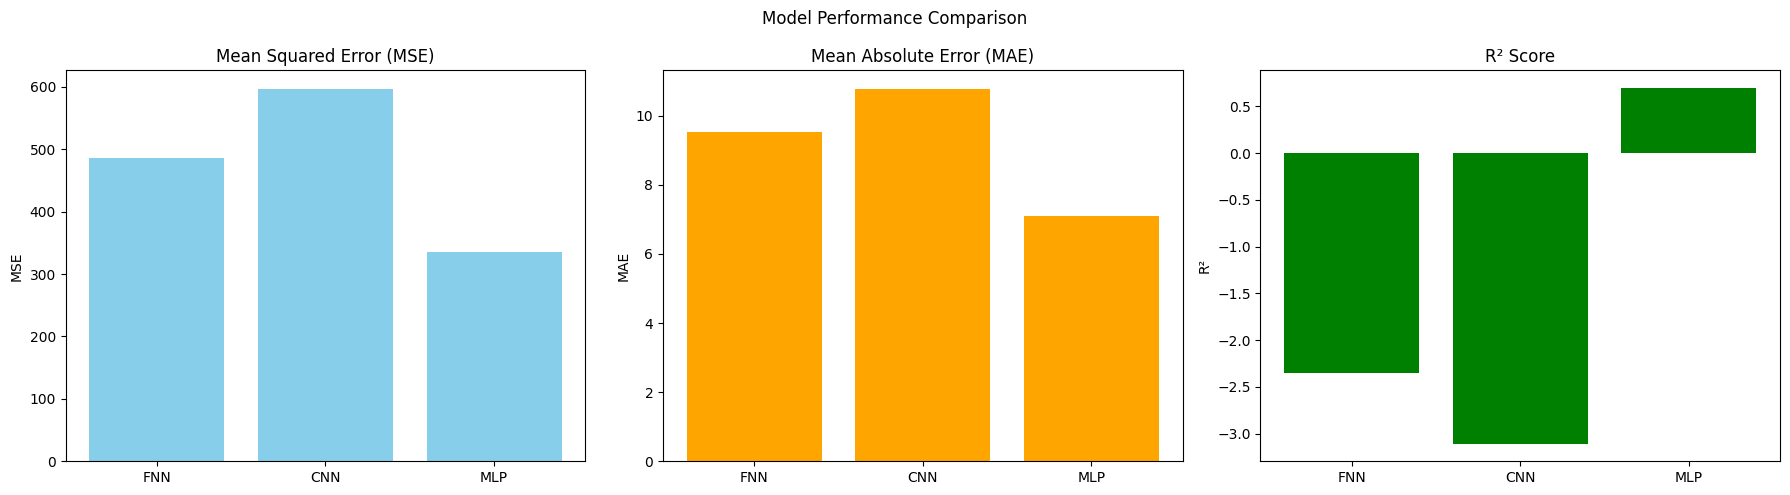

In [ ]:
import matplotlib.pyplot as plt

models = ['FNN', 'CNN', 'MLP']

mse_scores = [mse_fnn, mse_cnn, mse_mlp]
mae_scores = [mae_fnn, mae_cnn, mae_mlp]
r2_scores  = [r2_fnn, r2_cnn, r2_mlp]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].bar(models, mse_scores, color='skyblue')
axs[0].set_title('Mean Squared Error (MSE)')
axs[0].set_ylabel('MSE')

axs[1].bar(models, mae_scores, color='orange')
axs[1].set_title('Mean Absolute Error (MAE)')
axs[1].set_ylabel('MAE')

axs[2].bar(models, r2_scores, color='green')
axs[2].set_title('R² Score')
axs[2].set_ylabel('R²')

plt.suptitle('Model Performance Comparison')
plt.tight_layout()
plt.show()
